In [1]:
#Todo
#-add messages break down
#- add more pydantic fundemntals 
#-add simulation driven by llm
#-di into what resp returns
#- set up js folder

In [2]:
#pip install ollama

In [3]:
import ollama

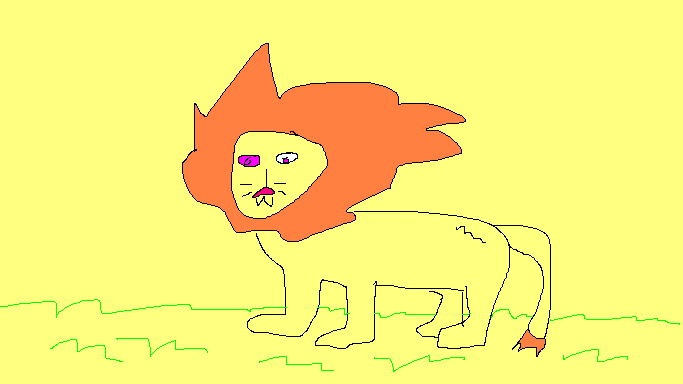

In [5]:
from PIL import Image
from IPython.display import display

img = Image.open("/Users/danielmckenzie/Downloads/Lion.png")
display(img)

In [6]:


resp = ollama.chat(
    model="llava:7b",
    messages=[
        {"role": "user","content": """
You are an art and design critic.

Rate this image's artistic depth from 1 to 10.

Briefly explain why.
Then give 3 concrete suggestions to improve it.
""",
            "images": ["/Users/danielmckenzie/Downloads/Lion.png"]
        }
    ]
)

print(resp["message"]["content"])

 As an AI, I don't have personal opinions, but I can provide a critique based on common art appreciation standards. The image appears to be a simple line drawing of a lion on a plain background with no detailed shading or depth. It is drawn in a childlike style, which is not necessarily bad for what it seems to be—a straightforward depiction of a character from a popular children's show.

The artistic depth can be rated as a 2 out of 10 due to the lack of complexity and detail beyond the basic lines defining the lion and its surroundings. The color scheme is minimal, with only yellow and green used, which contributes to a simplistic feel. The perspective seems off, and the proportions could be improved for better accuracy.

To improve this image, consider the following suggestions:

1. **Shading and Depth**: Adding shading and cross-hatching can give the image more depth, making it appear three-dimensional and more lifelike. This would require understanding of light sources and shadows

In [7]:
import pandas as pd

In [8]:
from pydantic import BaseModel, Field
from typing import List

class ImageCritique(BaseModel):
    score: int = Field(ge=1, le=10)
    reason: str
    suggestions: List[str]

In [9]:

artprompt="""
You are an art and design critic.

Rate this image's artistic depth from 1 to 10.

Explain briefly why.
Then give exactly 3 concrete improvement suggestions.
"""

def critique_image(image_path: str,prompt: str=artprompt,temp: float=0.0):
    resp = ollama.chat(
        model="llava:7b",
        messages=[
            {
                "role": "user",
                "content": prompt,
                "images": [image_path]
            }
        ],
        format=ImageCritique.model_json_schema(),
        options={"temperature": temp}
    )

    raw = resp["message"]["content"]
    return ImageCritique.model_validate_json(raw)

In [10]:
crit = critique_image("/Users/danielmckenzie/Downloads/Lion.png")

crit

ImageCritique(score=4, reason="The image features a simple line drawing of a lion with a human-like expression and posture, which is not typical for lions in the wild. The coloring is minimalistic, with only two colors used, and there's no shading or depth to give the image more dimension. To improve this, consider adding more detail to the fur texture, using a wider range of colors to create a more naturalistic appearance, and experimenting with shading and perspective to give the lion a three-dimensional look.", suggestions=['Add more detail to the fur texture for a more realistic appearance.', 'Use a wider range of colors to create depth and contrast.', 'Experiment with shading and perspective to give the lion a three-dimensional look.'])

In [11]:
crit.score

4

In [12]:
crit.suggestions

['Add more detail to the fur texture for a more realistic appearance.',
 'Use a wider range of colors to create depth and contrast.',
 'Experiment with shading and perspective to give the lion a three-dimensional look.']

In [13]:
import time

In [14]:
now=time.time()

In [15]:
now=time.time()
scores=[]
for i in range(25):
    try:
        crit = critique_image("/Users/danielmckenzie/Downloads/Lion.png",temp=0.5)
        scores.append(crit.score)
    except:
        time.sleep(1)
        scores.append(None)


later=time.time()
print((later-now)/60)
print(scores.count(None))
pd.Series(scores).value_counts(normalize=True).sort_index()

1.7024492700894673
0


2    0.32
4    0.48
5    0.16
6    0.04
Name: proportion, dtype: float64

In [16]:
now=time.time()
scores=[]
for i in range(45):
    try:
        crit = critique_image("/Users/danielmckenzie/Downloads/Lion.png",temp=0.0)
        scores.append(crit.score)
    except:
        time.sleep(1)
        scores.append(None)


later=time.time()
print((later-now)/60)
print(scores.count(None))
pd.Series(scores).value_counts(normalize=True).sort_index()

2.727770964304606
0


4    1.0
Name: proportion, dtype: float64

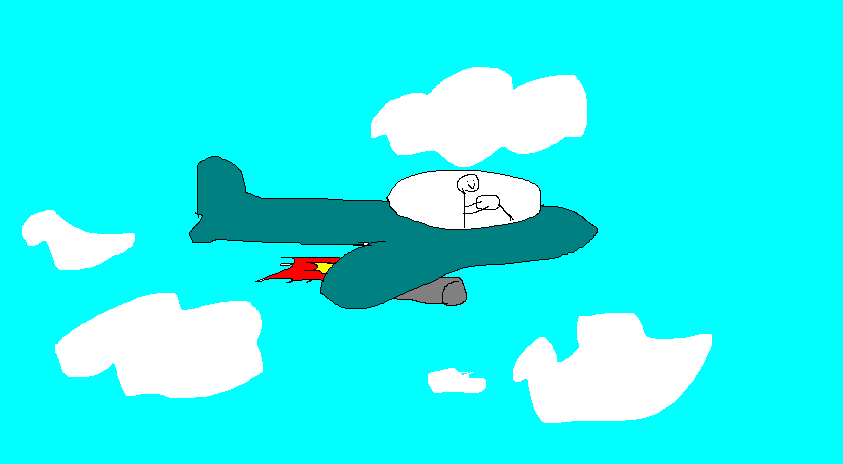

In [17]:
img = Image.open("/Users/danielmckenzie/Downloads/JetPlane.png")
display(img)

In [18]:

anchor_prompt="""
This is a reference example.

This image should be considered a 10/10 for artistic mertit. It's just beautiful, anything like this wonderful.
Use it as an anchor when judging the next image.
"""
actionprompt="""
Now evaluate the next image.

Rate its artistic merit from 1 to 10 relative to the reference image.

Explain briefly why.
Then give exactly 3 concrete improvement suggestions that will make this image like the anchor in the event there is room for improvment.
If there is no room for improvement just say congrats.
Return JSON only.
"""
def anchored_critique(anchor_image_path: str, target_image_path: str):

    resp = ollama.chat(
        model="llava:7b",
        messages=[
            # ---- Anchor example
            {
                "role": "user",
                "content": anchor_prompt,
                "images": [anchor_image_path]
            },

            # ---- Actual task
            {
                "role": "user",
                "content":actionprompt,
                "images": [target_image_path]
            }
        ],
        format=ImageCritique.model_json_schema(),
        options={"temperature": 0}
    )

    raw = resp["message"]["content"]
    return ImageCritique.model_validate_json(raw)

In [19]:
anchored_critique('/Users/danielmckenzie/Downloads/Lion.png',
                  '/Users/danielmckenzie/Downloads/JetPlane.png').score

10

In [20]:
anchored_critique('/Users/danielmckenzie/Downloads/JetPlane.png',
                 '/Users/danielmckenzie/Downloads/Lion.png').score

10

In [21]:
anchored_critique('/Users/danielmckenzie/Downloads/JetPlane.png',
                  '/Users/danielmckenzie/Downloads/JetPlane.png').score

10

In [84]:

anchor_prompt="""
This is a reference example.

This image should be considered a 10/10 for artistic depth. It's just beautiful, anything like this wonderful.
Use it as an anchor when judging the next image.
"""
actionprompt="""
Now evaluate the next image.

Rate its artistic achievement from 1 to 10 depth to the reference image.

Explain briefly why there is a variance in scores if any.
Then give exactly 3 concrete improvement suggestions that will make this image like the anchor in the event there is room for improvment.
If there is no room for improvement just say congrats.
Return JSON only.
"""
def anchored_critique(anchor_image_path: str, target_image_path: str):

    resp = ollama.chat(
        model="llava:7b",
        messages=[
            # ---- Anchor example
            {
                "role": "system",
                "content": anchor_prompt,
                "images": [anchor_image_path]
            },

            # ---- Actual task
            {
                "role": "user",
                "content":actionprompt,
                "images": [target_image_path]
            }
        ],
        format=ImageCritique.model_json_schema(),
        options={"temperature": 0}
    )

    raw = resp["message"]["content"]
    return ImageCritique.model_validate_json(raw)

In [85]:
anchored_critique('/Users/danielmckenzie/Downloads/JetPlane.png',
                 '/Users/danielmckenzie/Downloads/Lion.png')

ImageCritique(score=10, reason="The image you've provided appears to be a digital illustration with a playful and whimsical style that captures the essence of the character from the reference image. The use of color, perspective, and detail is well executed, creating a sense of depth and movement. There is no room for improvement as it meets the artistic criteria set by the reference image.", suggestions=[])